In [15]:
# --- 1. SETUP: IMPORTEREN VAN BIBLIOTHEKEN ---
# Stdlib
from collections import Counter
import re
import os

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
base_path = r"C:\Users\20193623\OneDrive - TU Eindhoven\BEP\Mijn project\data"
input_path = os.path.join(base_path, "1_Embedded_lies_dataset", "Embedded_lies_manprep.csv")
output_dir = os.path.join(base_path, "cleaned")


In [17]:
base_path = r"C:\Users\20193623\OneDrive - TU Eindhoven\BEP\Mijn project\data"
input_path = os.path.join(base_path, "1_Embedded_lies_dataset", "Embedded_lies_manprep.csv")
output_dir = os.path.join(base_path, "cleaned")

# Zorg ervoor dat de outputmap bestaat
os.makedirs(output_dir, exist_ok=True)

# Laad de dataset
df = pd.read_csv(input_path, sep=';')

# Romantische scenario's en 'None of them' verwijderen
romantic_scenarios_to_drop = [
    'Ending a long romantic relationship',
    'Cheating on your partner'
]

df_filtered = df[df['Event'] != 'None of them'].copy()
df_filtered = df_filtered[~df_filtered['Event'].isin(romantic_scenarios_to_drop)].copy()

print("Originele DataFrame shape:", df.shape)
print("Gefilterde DataFrame shape:", df_filtered.shape)

# Binary classificatie kolom toevoegen
positive_gain_events = [
    'A job interview for your dream job',
    'Being hospitalized and undergoing surgery',
    'Being involved in a car accident'
]
df_filtered['is_positive_gain'] = df_filtered['Event'].isin(positive_gain_events).astype(int)

# Sorteer de dataframe op basis van 'is_positive_gain'
df_filtered.sort_values(by='is_positive_gain', ascending=False, inplace=True)

# Herindexeren van de gefilterde DataFrame
df_filtered.reset_index(drop=True, inplace=True)

print("\nDataFrame met nieuwe binaire kolom:")
print(df_filtered[['Event', 'is_positive_gain']].head())
print("\nWaarden telling voor de nieuwe kolom:")
print(df_filtered['is_positive_gain'].value_counts())

# Opslaan van de verschillende dataframes
df_positive = df_filtered[df_filtered['is_positive_gain'] == 1].copy()
df_negative = df_filtered[df_filtered['is_positive_gain'] == 0].copy()

df_filtered.to_csv(os.path.join(output_dir, "df_filtered.csv"), index=False)
df_positive.to_csv(os.path.join(output_dir, "df_positive.csv"), index=False)
df_negative.to_csv(os.path.join(output_dir, "df_negative.csv"), index=False)

Originele DataFrame shape: (1042, 131)
Gefilterde DataFrame shape: (657, 131)

DataFrame met nieuwe binaire kolom:
                                Event  is_positive_gain
0  A job interview for your dream job                 1
1    Being involved in a car accident                 1
2  A job interview for your dream job                 1
3  A job interview for your dream job                 1
4  A job interview for your dream job                 1

Waarden telling voor de nieuwe kolom:
is_positive_gain
0    450
1    207
Name: count, dtype: int64


In [18]:
def extract_lies(dataframe):
    """
    Verzamelt alle individuele leugens uit de 'Embedded_lies_*' kolommen.

    Parameters:
    ----------
    dataframe : pd.DataFrame
        Het DataFrame waaruit de leugens moeten worden geëxtraheerd.

    Returns:
    -------
    list
        Een lijst van strings, elk een individuele leugen.
    """
    lie_columns = [f'Embedded_lies_{i}' for i in range(1, 21)]
    docs = []

    for _, row in dataframe.iterrows():
        for col in lie_columns:
            if col in dataframe.columns:
                lie_text = row[col]
                # Controleer op missende of lege waarden
                if pd.notna(lie_text) and str(lie_text).strip() != '':
                    docs.append(str(lie_text))
    return docs

docs_positive = extract_lies(df_positive)
docs_negative = extract_lies(df_negative)
docs = extract_lies(df_filtered)

print(f"\nAantal individuele 'Positive Gain' leugens: {len(docs_positive)}")
print(f"Aantal individuele 'Negative Gain' leugens: {len(docs_negative)}")
print(f"Totaal aantal individuele leugens: {len(docs)}")


Aantal individuele 'Positive Gain' leugens: 1114
Aantal individuele 'Negative Gain' leugens: 2142
Totaal aantal individuele leugens: 3256



Statistieken van Woordenaantal:
- Gemiddelde (Average): 9.38
- Mediaan (Median): 7.0
- Minimum (Min): 1
- Maximum (Max): 120


C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


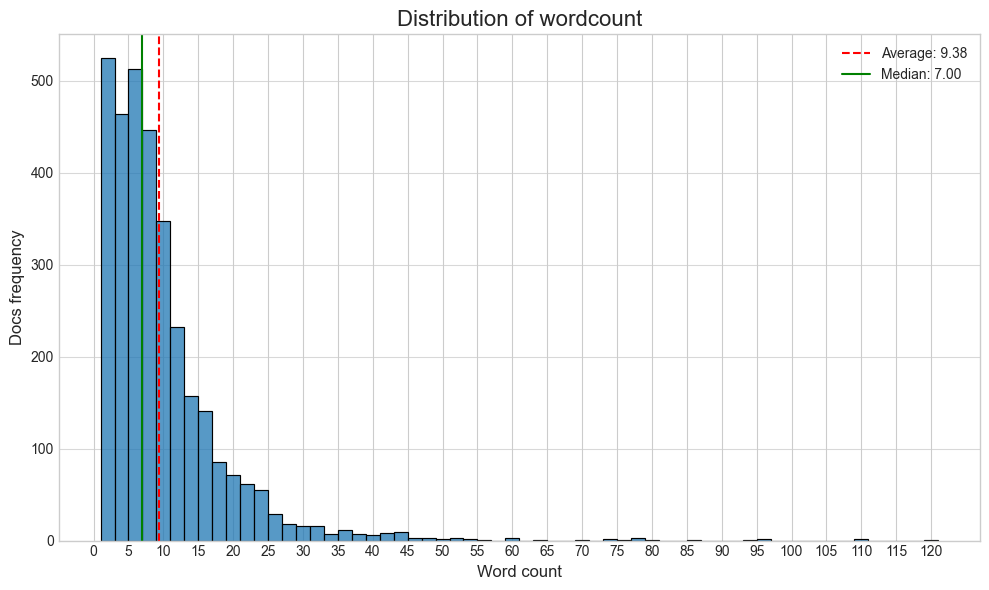

In [19]:
word_counts = [len(doc.split()) for doc in docs]

# Bereken en print de statistieken
average_words = np.mean(word_counts)
median_words = np.median(word_counts)
min_words = np.min(word_counts)
max_words = np.max(word_counts)

print("\nStatistieken van Woordenaantal:")
print(f"- Gemiddelde (Average): {average_words:.2f}")
print(f"- Mediaan (Median): {median_words}")
print(f"- Minimum (Min): {min_words}")
print(f"- Maximum (Max): {max_words}")

# Maak en sla de plot op
plt.figure(figsize=(10, 6))
sns.histplot(word_counts, bins=range(min_words, max_words + 2, 2))
plt.title('Distribution of wordcount', fontsize=16)
plt.xlabel('Word count', fontsize=12)
plt.ylabel('Docs frequency', fontsize=12)
plt.xticks(np.arange(0, max_words + 5, step=5))
plt.axvline(average_words, color='r', linestyle='--', label=f'Average: {average_words:.2f}')
plt.axvline(median_words, color='g', linestyle='-', label=f'Median: {median_words:.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'word_count_distribution.png'))
plt.show()


In [20]:
keep_cols = [
    "Participant_id",
    "Event",
    "False_event",
    "False_event_num_words",
    "merged_lies",
    "EL_num_words",
    "is_positive_gain"
]
embedded_cols = [c for c in df_filtered.columns if c.startswith("Embedded_lies_") and not any(x in c for x in ["_deceptiveness", "_centrality", "_source"])]
final_cols = keep_cols + embedded_cols

# Maak een 'long format' dataframe
df_long = df_filtered[final_cols].melt(
    id_vars=keep_cols,
    value_vars=embedded_cols,
    var_name="embedded_lie_num",
    value_name="embedded_lie"
)

# Verwijder lege rijen en reset de index
df_long.dropna(subset=["embedded_lie"], inplace=True)
df_long.reset_index(drop=True, inplace=True)
df_long["embedded_lie_num"] = df_long["embedded_lie_num"].str.extract(r"(\d+)").astype(int)
df_long.sort_values(by=["Participant_id", "Event", "embedded_lie_num"], inplace=True)

# Verwijder de "merged_lies" kolom omdat deze niet meer relevant is
df_long.drop(columns='merged_lies', inplace=True)
df_long.reset_index(drop=True, inplace=True)

# Controleer of de embedded lie in de False_event voorkomt
df_long['is_in_false_event'] = df_long.apply(
    lambda row: str(row['embedded_lie']).strip() in str(row['False_event']).strip(), axis=1
)

not_found_count = len(df_long[df_long['is_in_false_event'] == False])
df_long_clean = df_long[df_long['is_in_false_event'] == True].copy()
df_long_clean.drop(columns='is_in_false_event', inplace=True)

print(f"\nAantal rijen in de oorspronkelijke DataFrame: {len(df_long)}")
print(f"Aantal rijen verwijderd (leugen niet gevonden): {not_found_count}")
print(f"Aantal rijen in de opgeschoonde DataFrame: {len(df_long_clean)}")



Aantal rijen in de oorspronkelijke DataFrame: 3256
Aantal rijen verwijderd (leugen niet gevonden): 248
Aantal rijen in de opgeschoonde DataFrame: 3008



Woordtelling vergelijking na lengtecontrole:
       EL_num_words  enriched_lie_word_count_controlled
count   3008.000000                         3008.000000
mean      55.007314                           13.004322
std       43.119990                            7.527026
min        2.000000                            1.000000
25%       24.000000                            7.000000
50%       43.000000                           11.000000
75%       71.000000                           21.000000
max      303.000000                           30.000000

Statistieken van Woordenaantal:
- Gemiddelde (Average): 13.00
- Mediaan (Median): 11.0
- Minimum (Min): 1
- Maximum (Max): 30


C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


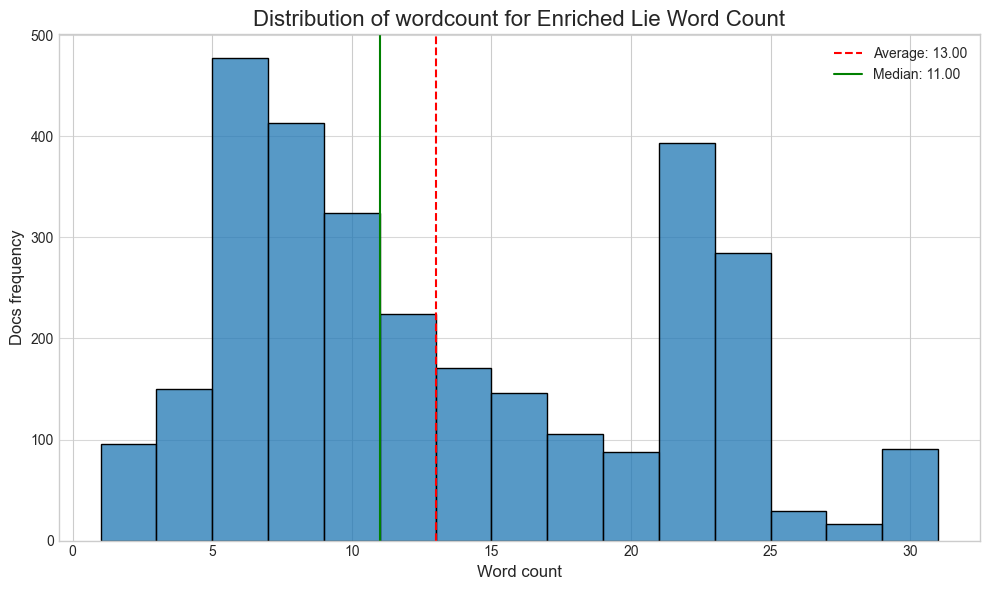


Final dataframe opgeslagen als 'df_long_clean.csv'

25.23% van de embedded_lies is verrijkt (veranderd t.o.v. origineel).


In [22]:
def enrich_lie_with_control(row, min_words=5, max_words=30, context_window=10):
    """
    Revised function to enrich a short 'embedded_lie' with context from 'False_event'
    using a fixed-size word window.
    """
    embedded_lie = str(row['embedded_lie']).strip()
    false_event = str(row['False_event']).strip()
    original_word_count = len(embedded_lie.split())
    
    # If the original lie is already within the desired range, return it.
    if min_words <= original_word_count <= max_words:
        return embedded_lie

    # If the lie is too long, truncate it to the maximum length.
    # This is a fallback to ensure no document exceeds the max_words limit.
    if original_word_count > max_words:
        return ' '.join(embedded_lie.split()[:max_words])

    # If the lie is too short, enrich it using a word-based window.
    if original_word_count < min_words:
        lie_words = embedded_lie.split()
        false_event_words = false_event.split()
        
        # Find the starting index of the lie in the false_event words.
        lie_start_index = -1
        for i in range(len(false_event_words)):
            if ' '.join(false_event_words[i:i + len(lie_words)]).lower() == embedded_lie.lower():
                lie_start_index = i
                break
        
        if lie_start_index != -1:
            # Calculate the start and end of the context window.
            start_slice = max(0, lie_start_index - context_window)
            end_slice = min(len(false_event_words), lie_start_index + len(lie_words) + context_window)
            
            enriched_words = false_event_words[start_slice:end_slice]
            
            # Ensure the enriched text is not too long.
            if len(enriched_words) > max_words:
                return ' '.join(enriched_words[:max_words])
            else:
                return ' '.join(enriched_words)

    # Return the original lie as a fallback if no context is found.
    return embedded_lie

df_long_clean['enriched_lie'] = df_long_clean.apply(enrich_lie_with_control, axis=1)
df_long_clean['enriched_lie_word_count_controlled'] = df_long_clean['enriched_lie'].str.split().str.len()

print("\nWoordtelling vergelijking na lengtecontrole:")
print(df_long_clean[['EL_num_words', 'enriched_lie_word_count_controlled']].describe())

word_counts = [len(doc.split()) for doc in df_long_clean['enriched_lie']]

# Bereken en print de statistieken
average_words = np.mean(word_counts)
median_words = np.median(word_counts)
min_words = np.min(word_counts)
max_words = np.max(word_counts)

print("\nStatistieken van Woordenaantal:")
print(f"- Gemiddelde (Average): {average_words:.2f}")
print(f"- Mediaan (Median): {median_words}")
print(f"- Minimum (Min): {min_words}")
print(f"- Maximum (Max): {max_words}")


# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(word_counts, bins=range(int(min_words), int(max_words) + 2, 2))

# Set titles and labels
plt.title('Distribution of wordcount for Enriched Lie Word Count', fontsize=16)
plt.xlabel('Word count', fontsize=12)
plt.ylabel('Docs frequency', fontsize=12)

# Set x-ticks
plt.xticks(np.arange(0, max_words + 5, step=5))

# Add vertical lines for average and median
plt.axvline(average_words, color='r', linestyle='--', label=f'Average: {average_words:.2f}')
plt.axvline(median_words, color='g', linestyle='-', label=f'Median: {median_words:.2f}')

# Add legend and grid
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

# Define output directory and save file
output_dir = './'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, 'enriched_lie_word_count_distribution.png'))

plt.show()


# Sla het uiteindelijke, schone dataframe op
df_long_clean.to_csv(os.path.join(output_dir, 'df_long_clean.csv'), index=False)
print("\nFinal dataframe opgeslagen als 'df_long_clean.csv'")

# Na het aanmaken van 'enriched_lie' kolom
df_long_clean['enriched_changed'] = df_long_clean['enriched_lie'] != df_long_clean['embedded_lie']

# Bereken percentage dat is aangepast
percent_changed = df_long_clean['enriched_changed'].mean() * 100
print(f"\n{percent_changed:.2f}% van de embedded_lies is verrijkt (veranderd t.o.v. origineel).")
